# Elections Dataset Deep Dive (Presentable)

This notebook audits `elections_master_dpi.parquet`, resolves strict-key duplicates deterministically, and produces an analysis-ready elections dataset plus audit artifacts. Results are descriptive only.

In [1]:
from datetime import datetime
from pathlib import Path

DATA_FILE = Path('data/processed/elections_master_dpi.parquet')
print('Run timestamp:', datetime.now().isoformat(timespec='seconds'))
if DATA_FILE.exists():
    print('Data file:', DATA_FILE, 'mtime:', datetime.fromtimestamp(DATA_FILE.stat().st_mtime))
else:
    print('Data file not found:', DATA_FILE)


Run timestamp: 2026-02-02T19:37:58
Data file not found: data/processed/elections_master.parquet


In [2]:

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import yaml
from datetime import datetime
from IPython.display import display

pd.options.mode.copy_on_write = True

%matplotlib inline


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
    'reports': ROOT / 'reports',
}


def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    table = pq.read_table(str(path))
    return table.to_pandas()


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, str(path))


AUDIT_LOG = []


def log_df(df: pd.DataFrame, step: str, keys: list[str] | None = None, notes: str = "") -> None:
    row = {
        'step': step,
        'n_rows': int(len(df)),
        'n_cols': int(df.shape[1]),
        'n_iso3': int(df['iso3'].nunique(dropna=True)) if 'iso3' in df.columns else None,
        'notes': notes,
    }
    if keys:
        row['n_dupe_rows_on_keys'] = int(df.duplicated(subset=keys).sum())
    AUDIT_LOG.append(row)


def assert_unique(df: pd.DataFrame, keys: list[str], allow_na: bool = False) -> None:
    if not allow_na and df[keys].isna().any().any():
        raise AssertionError(f"Missing values in key columns {keys}")
    dupes = df.duplicated(subset=keys)
    if dupes.any():
        raise AssertionError(f"Duplicate rows found on keys {keys}: {int(dupes.sum())}")


def assert_in_set(df: pd.DataFrame, col: str, allowed: set[str]) -> None:
    bad = set(df[col].dropna().unique()) - set(allowed)
    if bad:
        raise AssertionError(f"Column {col} has values outside allowed set: {bad}")


def assert_bounds(df: pd.DataFrame, col: str, lo: float, hi: float, tol: float = 1e-9, allow_na: bool = True) -> None:
    s = df[col]
    if not allow_na:
        s = s.dropna()
    bad = s[(s < lo - tol) | (s > hi + tol)]
    if not bad.empty:
        raise AssertionError(f"Column {col} has {len(bad)} values outside bounds [{lo},{hi}]")


def log_merge(left: pd.DataFrame, right: pd.DataFrame, on: list[str], how: str, step: str) -> pd.DataFrame:
    merged = left.merge(right, on=on, how=how, indicator=True)
    row = {
        'step': step,
        'left_rows': int(len(left)),
        'right_rows': int(len(right)),
        'merged_rows': int(len(merged)),
        'matched_rows': int((merged['_merge'] == 'both').sum()),
        'left_only_rows': int((merged['_merge'] == 'left_only').sum()),
        'right_only_rows': int((merged['_merge'] == 'right_only').sum()),
        'on_keys': ','.join(on),
        'how': how,
    }
    AUDIT_LOG.append(row)
    return merged.drop(columns=['_merge'])


def show_table(df: pd.DataFrame, title: str | None = None, n: int | None = None) -> None:
    if title:
        print(title)
    if n is None:
        display(df)
    else:
        display(df.head(n))


In [3]:
# Load elections master
PATH_ELECTIONS = PATHS['data_processed'] / 'elections_master_dpi.parquet'
PATH_ELECTIONS_EFW2000 = PATHS['data_processed'] / 'elections_master_efw2000.parquet'

df = read_parquet_pyarrow(PATH_ELECTIONS)
print('elections_master shape:', df.shape)
print('event_id min/max:', df['event_id'].min(), df['event_id'].max())

assert df['event_id'].notna().all()
assert df['event_id'].is_unique
log_df(df, 'loaded_elections_master', keys=['event_id'])


elections_master shape: (6544, 69)
event_id min/max: 0 6543


In [4]:
# Schema table
schema = pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str)})
write_parquet_pyarrow(schema, PATHS['reports'] / 'elections_audit' / 'schema.parquet')
show_table(schema, title='Schema Table')


Schema Table


,column,dtype
source_election_id,source_election_id,float64
country_name_raw,country_name_raw,object
country_cow,country_cow,float64
date,date,datetime64[ns]
year,year,float64
...,...,...
winner_ideo_gap,winner_ideo_gap,Float64
runnerup_ideo_ok,runnerup_ideo_ok,boolean
winner_ideo_ok,winner_ideo_ok,boolean
runnerup_ideo_source,runnerup_ideo_source,object


In [5]:
# Duplicate diagnostics

def dup_summary(df: pd.DataFrame, cols: list[str], key_name: str) -> dict:
    temp = df.copy()
    missing_any = temp[cols].isna().any(axis=1)
    dup_all = temp.duplicated(subset=cols, keep=False)
    dup_nonmissing = temp[~missing_any].duplicated(subset=cols, keep=False)
    return {
        'key_name': key_name,
        'cols': ','.join(cols),
        'n_rows': int(len(temp)),
        'rows_with_any_missing_key_component': int(missing_any.sum()),
        'duplicate_rows_including_missing': int(dup_all.sum()),
        'duplicate_rows_nonmissing_only': int(dup_nonmissing.sum()),
        'unique_key_values_nonmissing': int(temp[~missing_any][cols].drop_duplicates().shape[0]),
    }

key_specs = [
    (['event_id'], 'event_id'),
    (['source','source_election_id'], 'source+source_election_id'),
    (['iso3','office_type','election_date'], 'iso3+office_type+election_date'),
]
# Add composite year/month key
if 'election_month' in df.columns:
    df['election_month_int'] = df['election_month'].fillna(0).astype(int)
    key_specs.append((['iso3','office_type','election_year','election_month_int'], 'iso3+office_type+election_year+election_month_int'))
key_specs.append((['iso3','office_type','election_year'], 'iso3+office_type+election_year'))

summary = pd.DataFrame([dup_summary(df, cols, name) for cols, name in key_specs])
write_parquet_pyarrow(summary, PATHS['reports'] / 'elections_audit' / 'key_duplicates_summary.parquet')
show_table(summary, title='Duplicate Summary')


Duplicate Summary


,key_name,cols,n_rows,rows_with_any_missing_key_component,duplicate_rows_including_missing,duplicate_rows_nonmissing_only,unique_key_values_nonmissing
0,event_id,event_id,6544,0,0,0,6544
1,source+source_election_id,"source,source_election_id",6544,0,4,4,6542
2,iso3+office_type+election_date,"iso3,office_type,election_date",6544,373,336,6,6168
3,iso3+office_type+election_year+election_month_int,"iso3,office_type,election_year,election_month_int",6544,33,12,12,6505
4,iso3+office_type+election_year,"iso3,office_type,election_year",6544,33,402,398,6307


In [6]:
# Strict key duplicates with non-missing election_date
strict_key = ['iso3','office_type','election_date']
mask_date = df['election_date'].notna()
strict_dups = df[mask_date & df.duplicated(subset=strict_key, keep=False)]
write_parquet_pyarrow(strict_dups, PATHS['reports'] / 'elections_audit' / 'dup_rows_strict_key.parquet')
print('strict key dup rows:', len(strict_dups))
show_table(strict_dups, title='Strict Key Duplicates (if any)')

# source+source_election_id duplicates
source_dups = df[df.duplicated(subset=['source','source_election_id'], keep=False)]
write_parquet_pyarrow(source_dups, PATHS['reports'] / 'elections_audit' / 'dup_rows_source_id.parquet')
print('source+source_election_id dup rows:', len(source_dups))
show_table(source_dups, title='Source+Election ID Duplicates (if any)')


strict key dup rows: 6
Strict Key Duplicates (if any)


,source_election_id,country_name_raw,country_cow,date,year,month,type_election_raw,flag_two_round,flag_inconsequential,flag_coup,...,winner_ideo_vparty,runnerup_ideo_year,winner_ideo_year,runnerup_ideo_gap,winner_ideo_gap,runnerup_ideo_ok,winner_ideo_ok,runnerup_ideo_source,winner_ideo_source,election_month_int
5270,3861.0,Serbia,345.0,1945-11-11,1945.0,NaN,Parliamentary,NaN,NaN,NaN,...,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,None,11
6250,4841.0,Yugoslavia,345.0,1945-11-11,1945.0,NaN,Parliamentary,NaN,NaN,NaN,...,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,None,11
6344,1217.0,Kosovo,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,NaN,2007,<NA>,0.0,<NA>,True,<NA>,vparty_v2pariglef,None,11
6345,1218.0,Kosovo,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,-0.037,2010,2010,0.0,0.0,True,True,vparty_v2pariglef,vparty_v2pariglef,12
6434,1857.0,Kosovo,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,-0.037,2007,2007,0.0,0.0,True,True,vparty_v2pariglef,vparty_v2pariglef,11
6435,1858.0,Kosovo,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,-0.037,2010,2010,0.0,0.0,True,True,vparty_v2pariglef,vparty_v2pariglef,12


source+source_election_id dup rows: 4
Source+Election ID Duplicates (if any)


,source_election_id,country_name_raw,country_cow,date,year,month,type_election_raw,flag_two_round,flag_inconsequential,flag_coup,...,winner_ideo_vparty,runnerup_ideo_year,winner_ideo_year,runnerup_ideo_gap,winner_ideo_gap,runnerup_ideo_ok,winner_ideo_ok,runnerup_ideo_source,winner_ideo_source,election_month_int
6323,350.0,Iceland,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,NaN,1971,<NA>,45.0,<NA>,False,<NA>,vparty_v2pariglef,None,7
6324,350.0,Iceland,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,NaN,1971,<NA>,45.0,<NA>,False,<NA>,vparty_v2pariglef,None,10
6542,2331.0,Sri Lanka,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,None,1
6543,2331.0,Sri Lanka,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,None,3


In [7]:
# Deterministic duplicate resolver for strict key duplicates
ANALYSIS_COMPLETENESS_COLS = [
    'margin', 'share_1', 'share_2',
    'winner_partyfacts_id', 'runnerup_partyfacts_id',
    'winner_ideo_vparty', 'runnerup_ideo_vparty'
]

def resolve_strict_key_duplicates(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    key = ['iso3','office_type','election_date']
    df = df.copy()
    dup_mask = df['election_date'].notna() & df.duplicated(subset=key, keep=False)
    dups = df[dup_mask]
    kept_rows = []
    dropped_rows = []
    if dups.empty:
        return df, dups

    for _, g in dups.groupby(key, dropna=False):
        g = g.copy()
        g['completeness_score'] = g[ANALYSIS_COMPLETENESS_COLS].notna().sum(axis=1)
        if 'winner_ideo_ok' in g.columns and 'runnerup_ideo_ok' in g.columns:
            g['ideo_ok_both'] = g['winner_ideo_ok'].fillna(False) & g['runnerup_ideo_ok'].fillna(False)
        else:
            g['ideo_ok_both'] = False
        g['name_len'] = g['party_1_name_raw'].fillna('').str.len() + g['party_2_name_raw'].fillna('').str.len()
        g = g.sort_values(
            by=['completeness_score','ideo_ok_both','name_len','event_id'],
            ascending=[False, False, False, True]
        )
        keep = g.iloc[0].copy()
        keep['dup_resolution_reason'] = 'max_completeness;ideo_ok;name_len;min_event_id'
        kept_rows.append(keep)
        drop = g.iloc[1:].copy()
        drop['dup_resolution_reason'] = 'dropped_by_resolution_rule'
        dropped_rows.append(drop)

    kept_df = pd.DataFrame(kept_rows)
    dropped_df = pd.concat(dropped_rows, ignore_index=True) if dropped_rows else pd.DataFrame()

    # Remove all duplicates and add kept
    df_nodup = df[~dup_mask]
    df_resolved = pd.concat([df_nodup, kept_df], ignore_index=True)

    return df_resolved, dropped_df


# Apply resolver
resolved_df, dropped = resolve_strict_key_duplicates(df)
print('dropped rows:', len(dropped))
if len(dropped) > 0:
    write_parquet_pyarrow(dropped, PATHS['reports'] / 'elections_audit' / 'dup_rows_strict_key_dropped.parquet')
    show_table(dropped, title='Dropped Strict-Key Duplicates')

# Sanity check: no strict-key duplicates with nonmissing election_date
mask_date = resolved_df['election_date'].notna()
remaining = resolved_df[mask_date & resolved_df.duplicated(subset=['iso3','office_type','election_date'], keep=False)]
assert remaining.empty, f"Remaining strict-key duplicates: {len(remaining)}"

# Update df
if len(dropped) > 0:
    df = resolved_df.copy()
    log_df(df, 'after_strict_key_resolution')


dropped rows: 3
Dropped Strict-Key Duplicates


,source_election_id,country_name_raw,country_cow,date,year,month,type_election_raw,flag_two_round,flag_inconsequential,flag_coup,...,winner_ideo_gap,runnerup_ideo_ok,winner_ideo_ok,runnerup_ideo_source,winner_ideo_source,election_month_int,completeness_score,ideo_ok_both,name_len,dup_resolution_reason
0,1217.0,Kosovo,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,<NA>,True,<NA>,vparty_v2pariglef,None,11,5,False,53,dropped_by_resolution_rule
1,1858.0,Kosovo,NaN,NaT,NaN,NaN,None,NaN,NaN,NaN,...,0.0,True,True,vparty_v2pariglef,vparty_v2pariglef,12,7,True,6,dropped_by_resolution_rule
2,4841.0,Yugoslavia,345.0,1945-11-11,1945.0,NaN,Parliamentary,NaN,NaN,NaN,...,<NA>,<NA>,<NA>,None,None,11,3,False,24,dropped_by_resolution_rule


Coverage by Office Type


,office_type,n_events,share
0,parliamentary,5132,0.78459
1,presidential,1409,0.21541


Coverage by Source


,source,n_events,share
0,ned_parl,4899,0.748968
1,ned_pres,1409,0.215410
2,clea_lc,233,0.035621


Coverage by Share Metric


,share_metric,n_events,share
0,seat_share,4047,0.618713
1,vote_share,1465,0.223972
2,None,1029,0.157315


Coverage by Year (last 15 rows)


,election_year,n_events
220,2010.0,73
221,2011.0,83
222,2012.0,74
223,2013.0,71
224,2014.0,77
225,2015.0,77
226,2016.0,88
227,2017.0,66
228,2018.0,72
229,2019.0,86


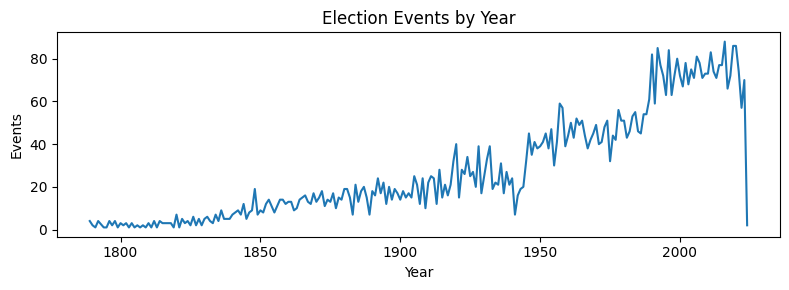

Coverage by Country (top 20)


,iso3,n_events,share
0,USA,175,0.026754
1,LBR,104,0.015900
2,PRT,100,0.015288
3,NAN,98,0.014982
4,SLV,90,0.013759
5,ARG,86,0.013148
6,BOL,86,0.013148
7,BRA,82,0.012536
8,COL,80,0.012231
9,DOM,79,0.012078


Coverage by Country (bottom 20)


,iso3,n_events,share
198,YEM,8,0.001223
199,BHR,8,0.001223
200,LBY,8,0.001223
201,SOM,8,0.001223
202,AGO,7,0.001070
203,OMN,7,0.001070
204,SRB,7,0.001070
205,MKD,6,0.000917
206,YMD,5,0.000764
207,ARE,5,0.000764


In [8]:
# Coverage diagnostics
coverage_office = df['office_type'].value_counts(dropna=False).rename_axis('office_type').reset_index(name='n_events')
coverage_office['share'] = coverage_office['n_events'] / len(df)
write_parquet_pyarrow(coverage_office, PATHS['reports'] / 'elections_audit' / 'coverage_by_office_type.parquet')
show_table(coverage_office, title='Coverage by Office Type')

coverage_source = df['source'].value_counts(dropna=False).rename_axis('source').reset_index(name='n_events')
coverage_source['share'] = coverage_source['n_events'] / len(df)
write_parquet_pyarrow(coverage_source, PATHS['reports'] / 'elections_audit' / 'coverage_by_source.parquet')
show_table(coverage_source, title='Coverage by Source')

coverage_share_metric = df['share_metric'].value_counts(dropna=False).rename_axis('share_metric').reset_index(name='n_events')
coverage_share_metric['share'] = coverage_share_metric['n_events'] / len(df)
write_parquet_pyarrow(coverage_share_metric, PATHS['reports'] / 'elections_audit' / 'coverage_by_share_metric.parquet')
show_table(coverage_share_metric, title='Coverage by Share Metric')

# Coverage by year
cov_year = df.groupby('election_year', dropna=False).size().reset_index(name='n_events')
write_parquet_pyarrow(cov_year, PATHS['reports'] / 'elections_audit' / 'coverage_by_year.parquet')
show_table(cov_year.tail(15), title='Coverage by Year (last 15 rows)')

# Plot coverage by year
plt.figure(figsize=(8,3))
plt.plot(cov_year['election_year'], cov_year['n_events'])
plt.title('Election Events by Year')
plt.xlabel('Year')
plt.ylabel('Events')
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'elections_audit' / 'figures' / 'coverage_by_year.png', dpi=150)
plt.show()

# Coverage by country
cov_country = df['iso3'].fillna('MISSING_ISO3').value_counts().reset_index()
cov_country.columns = ['iso3','n_events']
cov_country['share'] = cov_country['n_events'] / len(df)
write_parquet_pyarrow(cov_country, PATHS['reports'] / 'elections_audit' / 'coverage_by_country.parquet')
show_table(cov_country.head(20), title='Coverage by Country (top 20)')
show_table(cov_country.tail(20), title='Coverage by Country (bottom 20)')


In [9]:
# ISO3 mapping audit
iso3_status = df['iso3_match_status'].value_counts(dropna=False).reset_index()
iso3_status.columns = ['iso3_match_status','n_events']
iso3_status['share'] = iso3_status['n_events'] / len(df)
write_parquet_pyarrow(iso3_status, PATHS['reports'] / 'elections_audit' / 'iso3_match_status.parquet')
show_table(iso3_status, title='ISO3 Match Status')

missing_iso3 = df[df['iso3'].isna()][['country_name_raw','election_year','source','office_type','event_id']]
write_parquet_pyarrow(missing_iso3, PATHS['reports'] / 'elections_audit' / 'iso3_missing.parquet')
print('missing iso3 rows:', len(missing_iso3))
show_table(missing_iso3, title='Missing ISO3 Rows')


ISO3 Match Status


,iso3_match_status,n_events,share
0,cow_latest_no_year,5560,0.850023
1,cow_latest,423,0.064669
2,name_pycountry_exact,205,0.031341
3,pycountry_exact,113,0.017276
4,efw_exact,93,0.014218
5,cow_year,88,0.013454
6,manual,27,0.004128
7,name_unmatched,26,0.003975
8,name_manual,6,0.000917


missing iso3 rows: 33
Missing ISO3 Rows


,country_name_raw,election_year,source,office_type,event_id
1136,Serbia and Montenegro,2000.0,ned_pres,presidential,1136
1174,Somaliland,2003.0,ned_pres,presidential,1174
1175,Somaliland,2010.0,ned_pres,presidential,1175
1176,Somaliland,2017.0,ned_pres,presidential,1176
4496,Netherlands Antilles,1937.0,ned_parl,parliamentary,4496
4497,Netherlands Antilles,1941.0,ned_parl,parliamentary,4497
4498,Netherlands Antilles,1945.0,ned_parl,parliamentary,4498
4499,Netherlands Antilles,1949.0,ned_parl,parliamentary,4499
4500,Netherlands Antilles,1950.0,ned_parl,parliamentary,4500
4501,Netherlands Antilles,1954.0,ned_parl,parliamentary,4501


Date Precision Distribution


,date_precision,n_events,share
0,day,5958,0.910870
1,year,349,0.053356
2,month,234,0.035774


Pct Missing election_date by Precision


,date_precision,pct_missing_election_date
0,day,0.00000
1,month,0.42735
2,year,100.00000


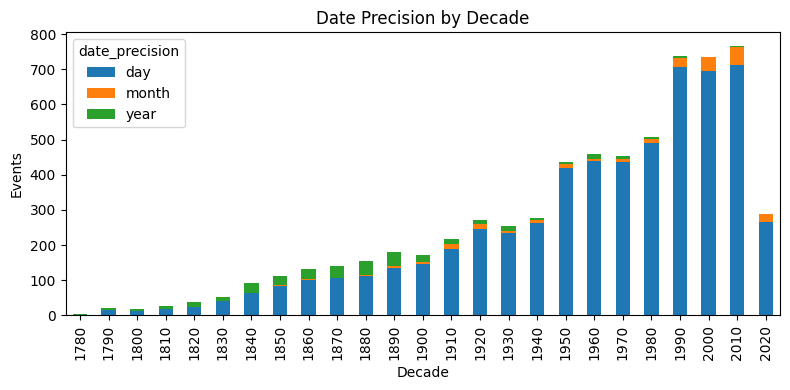

In [10]:
# Date precision audit
precision = df['date_precision'].value_counts(dropna=False).reset_index()
precision.columns = ['date_precision','n_events']
precision['share'] = precision['n_events'] / len(df)
write_parquet_pyarrow(precision, PATHS['reports'] / 'elections_audit' / 'date_precision.parquet')
show_table(precision, title='Date Precision Distribution')

# Missingness of election_date by precision
prec_missing = df.groupby('date_precision')['election_date'].apply(lambda s: s.isna().mean()*100).reset_index(name='pct_missing_election_date')
write_parquet_pyarrow(prec_missing, PATHS['reports'] / 'elections_audit' / 'date_precision_missing_election_date.parquet')
show_table(prec_missing, title='Pct Missing election_date by Precision')

# Plot stacked bar by decade
if 'election_year' in df.columns:
    df['decade'] = (df['election_year'].fillna(0).astype(int) // 10) * 10
    decade_tab = df.pivot_table(index='decade', columns='date_precision', values='event_id', aggfunc='count', fill_value=0)
    decade_tab.plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title('Date Precision by Decade')
    plt.xlabel('Decade')
    plt.ylabel('Events')
    plt.tight_layout()
    plt.savefig(PATHS['reports'] / 'elections_audit' / 'figures' / 'date_precision_by_decade.png', dpi=150)
    plt.show()


margin mismatches: 0
Largest Margins (top 20)


,event_id,iso3,office_type,election_year,margin,flag_unopposed,flag_plebiscite,share_metric
1199,1199,SYR,presidential,1985.0,100.0,NaN,1.0,vote_share
165,165,CAF,presidential,1964.0,100.0,NaN,1.0,vote_share
1201,1201,SYR,presidential,1999.0,100.0,NaN,1.0,vote_share
394,394,EGY,presidential,1958.0,100.0,NaN,1.0,vote_share
395,395,EGY,presidential,1965.0,100.0,NaN,1.0,vote_share
1200,1200,SYR,presidential,1991.0,100.0,NaN,1.0,vote_share
211,211,COL,presidential,1949.0,100.0,1.0,NaN,vote_share
1173,1173,SOM,presidential,1986.0,100.0,NaN,1.0,vote_share
771,771,LBR,presidential,1959.0,100.0,NaN,NaN,vote_share
2546,2546,CZE,parliamentary,1964.0,100.0,NaN,NaN,seat_share


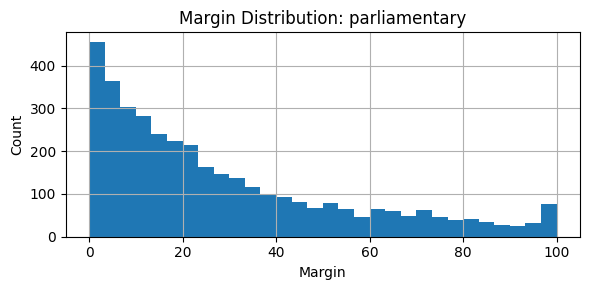

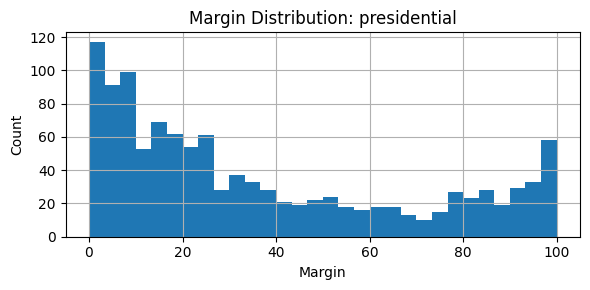

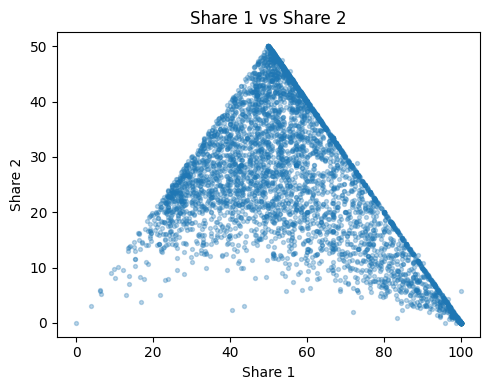

In [11]:
# Shares/margins audit
# Bounds checks (non-fatal; log warnings)
for col in ['share_1','share_2','margin']:
    if col in df.columns:
        try:
            assert_bounds(df, col, 0, 100, allow_na=True)
        except AssertionError as e:
            print('WARNING:', e)

# Check margin consistency where share_1/share_2 not missing
if {'share_1','share_2','margin'}.issubset(df.columns):
    tmp = df[['share_1','share_2','margin']].dropna()
    mismatch = (tmp['margin'] - (tmp['share_1'] - tmp['share_2'])).abs() > 1e-6
    print('margin mismatches:', int(mismatch.sum()))

# Largest margins table
largest_margin = df[['event_id','iso3','office_type','election_year','margin','flag_unopposed','flag_plebiscite','share_metric']].sort_values('margin', ascending=False).head(20)
write_parquet_pyarrow(largest_margin, PATHS['reports'] / 'elections_audit' / 'largest_margins.parquet')
show_table(largest_margin, title='Largest Margins (top 20)')

# Histogram of margin by office_type
if 'margin' in df.columns:
    for office in ['parliamentary','presidential']:
        subset = df[df['office_type'] == office]
        plt.figure(figsize=(6,3))
        subset['margin'].dropna().hist(bins=30)
        plt.title(f'Margin Distribution: {office}')
        plt.xlabel('Margin')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.savefig(PATHS['reports'] / 'elections_audit' / 'figures' / f'margin_hist_{office}.png', dpi=150)
        plt.show()

# Share_1 vs share_2 scatter
if {'share_1','share_2'}.issubset(df.columns):
    plt.figure(figsize=(5,4))
    plt.scatter(df['share_1'], df['share_2'], alpha=0.3, s=8)
    plt.title('Share 1 vs Share 2')
    plt.xlabel('Share 1')
    plt.ylabel('Share 2')
    plt.tight_layout()
    plt.savefig(PATHS['reports'] / 'elections_audit' / 'figures' / 'share1_vs_share2.png', dpi=150)
    plt.show()


In [12]:
# Party matching audit
winner_status = df['winner_party_match_status'].value_counts(dropna=False).reset_index()
winner_status.columns = ['winner_party_match_status','n_events']
winner_status['share'] = winner_status['n_events'] / len(df)
write_parquet_pyarrow(winner_status, PATHS['reports'] / 'elections_audit' / 'winner_party_match_status.parquet')
show_table(winner_status, title='Winner Party Match Status')

runner_status = df['runnerup_party_match_status'].value_counts(dropna=False).reset_index()
runner_status.columns = ['runnerup_party_match_status','n_events']
runner_status['share'] = runner_status['n_events'] / len(df)
write_parquet_pyarrow(runner_status, PATHS['reports'] / 'elections_audit' / 'runnerup_party_match_status.parquet')
show_table(runner_status, title='Runner-up Party Match Status')

# EFW post-2000 missing ideology iso3 list
if 'efw_post2000' in df.columns:
    df_post = df[df['efw_post2000'] == True]
    iso3_missing_ideo = df_post[df_post['winner_ideo_vparty'].isna()].groupby('iso3').size().reset_index(name='n_events_missing_winner_ideo')
    iso3_missing_ideo = iso3_missing_ideo.sort_values('n_events_missing_winner_ideo', ascending=False)
    iso3_missing_ideo.to_csv(PATHS['reports'] / 'elections_audit' / 'efw2000_missing_ideology_iso3.csv', index=False)
    show_table(iso3_missing_ideo.head(20), title='EFW Post-2000: Missing Winner Ideology (top 20)')

# Manual override backlog
backlog = df[(df['margin'].notna()) & (
    df['winner_party_match_status'].isin(['ambiguous_exact','ambiguous_fuzzy','matched_fuzzy_tie']) |
    df['runnerup_party_match_status'].isin(['ambiguous_exact','ambiguous_fuzzy','matched_fuzzy_tie'])
)]
backlog_tab = backlog.groupby('iso3').size().reset_index(name='n_events_backlog')
backlog_tab = backlog_tab.sort_values('n_events_backlog', ascending=False)
write_parquet_pyarrow(backlog_tab, PATHS['reports'] / 'elections_audit' / 'party_match_backlog.parquet')
show_table(backlog_tab.head(20), title='Manual Override Backlog (top 20)')


Winner Party Match Status


,winner_party_match_status,n_events,share
0,matched_exact,2859,0.437089
1,unmatched,1306,0.199664
2,missing,1050,0.160526
3,ambiguous_exact,605,0.092494
4,generic,360,0.055037
5,no_candidates,164,0.025073
6,matched_fuzzy,154,0.023544
7,ambiguous_fuzzy,29,0.004434
8,matched_fuzzy_tie,14,0.002140


Runner-up Party Match Status


,runnerup_party_match_status,n_events,share
0,matched_exact,2323,0.355144
1,missing,1770,0.270601
2,unmatched,1227,0.187586
3,ambiguous_exact,560,0.085614
4,generic,324,0.049534
5,matched_fuzzy,163,0.024920
6,no_candidates,127,0.019416
7,ambiguous_fuzzy,29,0.004434
8,matched_fuzzy_tie,18,0.002752


EFW Post-2000: Missing Winner Ideology (top 20)


,iso3,n_events_missing_winner_ideo
37,ECU,14
22,CHL,13
72,KWT,12
88,MNE,11
15,BLR,11
69,KGZ,10
2,ARG,10
28,COM,9
9,BEN,9
67,KAZ,9


Manual Override Backlog (top 20)


,iso3,n_events_backlog
25,CAN,40
6,AUS,32
111,NZL,23
66,IRL,21
115,PHL,18
161,ZWE,17
153,VCT,16
54,GMB,16
107,NGA,16
52,GIB,16


In [13]:
# Ideology audit + derived political variables

df = df.copy()

# Derived ideology variables
if {'winner_ideo_vparty','runnerup_ideo_vparty'}.issubset(df.columns):
    df['ideo_diff'] = df['winner_ideo_vparty'] - df['runnerup_ideo_vparty']
    df['market_winner'] = np.where(df['ideo_diff'].notna(), df['ideo_diff'] >= 0, np.nan)
    df['market_winner'] = df['market_winner'].astype('boolean')

    df['market_margin'] = np.where(
        df['ideo_diff'].notna() & df['margin'].notna(),
        np.where(df['ideo_diff'] >= 0, df['margin'], -df['margin']),
        np.nan
    )

    for thr in [1,2,5,10]:
        col = f'close_{thr}pp'
        df[col] = pd.Series(
            np.where(df['market_margin'].notna(), np.abs(df['market_margin']) <= thr, np.nan),
            dtype='boolean'
        )

if {'winner_ideo_ok','runnerup_ideo_ok'}.issubset(df.columns):
    df['ideo_both_ok'] = (df['winner_ideo_ok'].fillna(False) & df['runnerup_ideo_ok'].fillna(False)).astype('boolean')
else:
    df['ideo_both_ok'] = pd.Series([False]*len(df), dtype='boolean')

# RD-ready flag
if 'market_margin' in df.columns:
    df['analysis_ideo_ok'] = (df['ideo_both_ok'] & df['market_margin'].notna()).astype('boolean')

# Sanity checks
if 'market_margin' in df.columns:
    bad = df[df['market_margin'].notna() & (df['margin'].isna())]
    assert bad.empty, f"market_margin nonmissing but margin missing: {len(bad)}"

# Summary table for market_margin density
if 'market_margin' in df.columns:
    both_ideo = df[df['market_margin'].notna()]
    thresholds = [0.5,1,2,5,10]
    rows = []
    for thr in thresholds:
        rows.append({'abs_market_margin_leq': thr, 'n_events': int((both_ideo['market_margin'].abs() <= thr).sum()), 'share': float((both_ideo['market_margin'].abs() <= thr).mean())})
    density = pd.DataFrame(rows)
    write_parquet_pyarrow(density, PATHS['reports'] / 'elections_audit' / 'market_margin_density.parquet')
    show_table(density, title='Market Margin Density')


Market Margin Density


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_14328/2033069711.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ideo_both_ok'] = (df['winner_ideo_ok'].fillna(False) & df['runnerup_ideo_ok'].fillna(False)).astype('boolean')


,abs_market_margin_leq,n_events,share
0,0.5,33,0.026721
1,1.0,66,0.053441
2,2.0,114,0.092308
3,5.0,249,0.201619
4,10.0,451,0.365182


In [14]:
# Convert flag_* columns to boolean
flag_cols = [c for c in df.columns if c.startswith('flag_')]
for col in flag_cols:
    df[col] = df[col].fillna(0).astype(int).astype(bool)

log_df(df, 'after_flag_bool_conversion')


In [15]:
# Missingness table
missing = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct_overall': (df.isna().mean()*100).round(2),
})
missing_by_office = (
    df.groupby('office_type')
      .apply(lambda g: g.isna().mean()*100)
      .T
      .rename(columns=lambda c: f'missing_pct_{c}')
      .reset_index()
      .rename(columns={'index':'column'})
)
missing = missing.merge(missing_by_office, on='column', how='left').sort_values('missing_pct_overall', ascending=False)
write_parquet_pyarrow(missing, PATHS['reports'] / 'elections_audit' / 'missingness.parquet')
show_table(missing.head(30), title='Missingness (top 30 rows)')


Missingness (top 30 rows)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_14328/2219980979.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isna().mean()*100)


,column,dtype,missing_n,missing_pct_overall,missing_pct_parliamentary,missing_pct_presidential
73,dup_resolution_reason,object,6538,99.95,99.941543,100.000000
72,name_len,float64,6538,99.95,99.941543,100.000000
71,ideo_ok_both,object,6538,99.95,99.941543,100.000000
70,completeness_score,float64,6538,99.95,99.941543,100.000000
5,month,float64,6347,97.03,96.804365,97.870830
38,id,float64,6308,96.44,95.459860,100.000000
39,country_code_clea,float64,6308,96.44,95.459860,100.000000
14,candidate_2_name_raw,object,5398,82.53,100.000000,18.878637
81,close_10pp,boolean,5306,81.12,81.410756,80.056778
75,ideo_diff,float64,5306,81.12,81.410756,80.056778


In [16]:
# Data contract
ELECTIONS_CONTRACT = {
    'primary_key': ['event_id'],
    'required_columns': ['event_id','iso3','office_type','election_year','date_precision'],
    'categorical_domains': {
        'office_type': ['parliamentary','presidential'],
        'date_precision': ['day','month','year']
    },
    'bounds': {
        'share_1': [0,100],
        'share_2': [0,100],
        'margin': [0,100]
    },
    'invariants': [
        'event_id unique',
        'if share_2 notna then margin == share_1 - share_2 (tolerance 1e-6)',
        'if date_precision == day then election_date notna'
    ]
}

contract_path = PATHS['reports'] / 'elections_contract.yml'
contract_path.parent.mkdir(parents=True, exist_ok=True)
with open(contract_path, 'w') as f:
    yaml.safe_dump(ELECTIONS_CONTRACT, f, sort_keys=False)
print('wrote contract to', contract_path)
show_table(pd.DataFrame({'contract_key': list(ELECTIONS_CONTRACT.keys())}), title='Contract keys')


wrote contract to /Users/gabrielsaco/Documents/GitHub/economic-freedom/reports/elections_contract.yml
Contract keys


,contract_key
0,primary_key
1,required_columns
2,categorical_domains
3,bounds
4,invariants


In [17]:
# Save analysis dataset and audit log
analysis_path = PATHS['data_processed'] / 'elections_master_analysis.parquet'
write_parquet_pyarrow(df, analysis_path)
print('wrote', analysis_path)

# Audit log
if AUDIT_LOG:
    audit_df = pd.DataFrame(AUDIT_LOG)
    write_parquet_pyarrow(audit_df, PATHS['reports'] / 'elections_audit' / 'audit_log.parquet')
    show_table(audit_df, title='Audit Log')


wrote /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/processed/elections_master_analysis.parquet
Audit Log


,step,n_rows,n_cols,n_iso3,notes,n_dupe_rows_on_keys
0,loaded_elections_master,6544,69,217,,0.0
1,after_strict_key_resolution,6541,74,217,,NaN
2,after_flag_bool_conversion,6541,84,217,,NaN
